### Build A Basic ChatBot with Langgraph (GRAPH API)

In [3]:
from typing import Annotated

from typing_extensions import TypedDict

from langgraph.graph import StateGraph, START, END # Nodes
from langgraph.graph.message import add_messages # add_messages is one the reducer to add messages(storing content of messages) instead of replacing the messages 

In [4]:
class State(TypedDict):
    # Messages have the type "list". The 'add_messages' function
    # in the annotation defines how this state key should be updated
    # (in this case, it appends messages to the list, rather than overwriting them)
    messages:Annotated[list,add_messages]


graph_builder =  StateGraph(State)

In [5]:
graph_builder

In [6]:
import os 
from dotenv import load_dotenv
load_dotenv()

True

In [7]:
from langchain_groq import ChatGroq

llm = ChatGroq(model="llama-3.3-70b-versatile")


In [8]:
llm    # Now our LLM is ready , let's get further to build ChatBot

ChatGroq(metadata={'lc_versions': {'langchain-core': '1.4.8', 'langchain': '1.3.11'}}, output_version=None, profile={'name': 'Llama 3.3 70B Versatile', 'release_date': '2024-12-06', 'last_updated': '2024-12-06', 'open_weights': True, 'max_input_tokens': 131072, 'max_output_tokens': 32768, 'text_inputs': True, 'image_inputs': False, 'audio_inputs': False, 'video_inputs': False, 'text_outputs': True, 'image_outputs': False, 'audio_outputs': False, 'video_outputs': False, 'reasoning_output': False, 'tool_calling': True, 'attachment': False, 'temperature': True}, client=<groq.resources.chat.completions.Completions object at 0x00000212D2953320>, async_client=<groq.resources.chat.completions.AsyncCompletions object at 0x00000212D30E3770>, model_name='llama-3.3-70b-versatile', model_kwargs={}, groq_api_key=SecretStr('**********'), groq_api_base=None, groq_proxy=None)

In [9]:
## Node functionality 

def chatbot(state:State):
    return {"messages":[llm.invoke(state["messages"])]
    }

### Our Goal Graph 

   start

   |

  chatbot

   |
     
   end

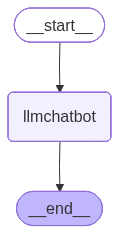

In [10]:
graph_builder=StateGraph(State)

# Adding Node
graph_builder.add_node("llmchatbot",chatbot)

# Adding Edges
graph_builder.add_edge(START,"llmchatbot")
graph_builder.add_edge("llmchatbot",END)

graph = graph_builder.compile()
graph

In [11]:
graph.invoke({"messages":"Hi"})

{'messages': [HumanMessage(content='Hi', additional_kwargs={}, response_metadata={}, id='e6e811dc-03bf-414c-9273-a333a5549949'),
  AIMessage(content="It's nice to meet you. Is there something I can help you with or would you like to chat?", additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 23, 'prompt_tokens': 36, 'total_tokens': 59, 'completion_time': 0.054013124, 'completion_tokens_details': None, 'prompt_time': 0.001965494, 'prompt_tokens_details': None, 'queue_time': 0.056272946, 'total_time': 0.055978618}, 'model_name': 'llama-3.3-70b-versatile', 'system_fingerprint': 'fp_dae98b5ecb', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019f0d9e-7215-7723-bc4d-ae204fadda87-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 36, 'output_tokens': 23, 'total_tokens': 59})]}

In [12]:
for event in graph.stream({"messages":"Hi, How are you?"}):
    for value in event.values():
        print(value["messages"][-1].content)

I'm doing well, thanks for asking. I'm a large language model, so I don't have feelings or emotions like humans do, but I'm always happy to chat and help with any questions or topics you'd like to discuss. How about you? How's your day going?


### ChatBot with Tool

TAVILY SEARCH - Internet Search tool

and
 
CUSTOM TOOLS

In [13]:
from langchain_tavily import TavilySearch

tool = TavilySearch(max_result=2)
tools = [tool]

tool.invoke("What is LangGraph?")

{'query': 'What is LangGraph?',
 'follow_up_questions': None,
 'answer': None,
 'images': [],
 'results': [{'url': 'https://www.ibm.com/think/topics/langgraph',
   'title': 'What is LangGraph? - IBM',
   'content': '*   [Overview](https://www.ibm.com/think/topics/ai-agents#7281535). *   [What is agentic AI?](https://www.ibm.com/think/topics/agentic-ai#2095054954). *   [Overview](https://www.ibm.com/think/topics/ai-agent-development#1083937704). *   [Building AI agents](https://www.ibm.com/think/topics/how-to-build-an-ai-agent#1083937709). *   [Overview](https://www.ibm.com/think/topics/ai-agent-types#72820454). *   [Overview](https://www.ibm.com/think/topics/components-of-ai-agents#498277090). *   [Communication](https://www.ibm.com/think/topics/ai-agent-communication#498277088). *   [Learning](https://www.ibm.com/think/topics/ai-agent-learning#498277087). *   [Memory](https://www.ibm.com/think/topics/ai-agent-memory#498277086). *   [Perception](https://www.ibm.com/think/topics/ai-agen

In [14]:
## CUSTOM FUNCTION

## below part is actually called as a doc string which is quoted in paranthesis 

def multiply(a:int,b:int)->int:
    """Multiply a and b
                                        
    Args:
        a (int): first int
        b (int): second int

    Returns:
        int: output int 
     """
    return a*b

In [17]:
tools=[tool,multiply]

In [16]:
# Binding the tools to the LLM
llm_with_tool=llm.bind_tools(tools)

In [18]:
llm_with_tool

_ChatModelBinding(bound=ChatGroq(metadata={'lc_versions': {'langchain-core': '1.4.8', 'langchain': '1.3.11'}}, output_version=None, profile={'name': 'Llama 3.3 70B Versatile', 'release_date': '2024-12-06', 'last_updated': '2024-12-06', 'open_weights': True, 'max_input_tokens': 131072, 'max_output_tokens': 32768, 'text_inputs': True, 'image_inputs': False, 'audio_inputs': False, 'video_inputs': False, 'text_outputs': True, 'image_outputs': False, 'audio_outputs': False, 'video_outputs': False, 'reasoning_output': False, 'tool_calling': True, 'attachment': False, 'temperature': True}, client=<groq.resources.chat.completions.Completions object at 0x00000212D2953320>, async_client=<groq.resources.chat.completions.AsyncCompletions object at 0x00000212D30E3770>, model_name='llama-3.3-70b-versatile', model_kwargs={}, groq_api_key=SecretStr('**********'), groq_api_base=None, groq_proxy=None), kwargs={'tools': [{'type': 'function', 'function': {'name': 'tavily_search', 'description': 'A search 

There are two important things :

1 -  Binding : LLM + TOOLS

2 - 

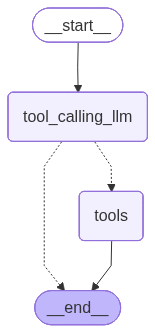

In [19]:
## State graph
from langgraph.graph import StateGraph,START,END
from langgraph.prebuilt import ToolNode
from langgraph.prebuilt import tools_condition


## Node Definition
def tool_calling_llm(state:State):
    return {"messages":[llm_with_tool.invoke(state["messages"])]}


## Graph 
builder = StateGraph(State)
builder.add_node("tool_calling_llm",tool_calling_llm)
builder.add_node("tools",ToolNode(tools))

## Adding Edges

builder.add_edge(START,"tool_calling_llm")
builder.add_conditional_edges(
    "tool_calling_llm",
    # if the latest message (result) from assistant is a tool call -> tools_condition routes to tools
    # if the latest message (result) from assistant is not a tool call -> tools_condition routs to END
    tools_condition
)
builder.add_edge("tools",END)

# Compile the graph

graph=builder.compile()
graph

In [20]:
response=graph.invoke({"messages":"What is the recent AI News??"})
for m in response['messages']:
    m.pretty_print()

================================ Human Message =================================

What is the recent AI News??
================================== Ai Message ==================================
Tool Calls:
  tavily_search (knq46stk5)
 Call ID: knq46stk5
  Args:
    query: Recent AI News
    search_depth: advanced
    time_range: day
================================= Tool Message =================================
Name: tavily_search

{"query": "Recent AI News", "follow_up_questions": null, "answer": null, "images": [], "results": [{"url": "https://news.cgtn.com/news/2026-06-27/MWC26-AI-meets-telecoms-as-China-pushes-digital-economy-1OjQeiyVRsc/p.html", "title": "MWC26: AI meets telecoms as China pushes digital economy - CGTN", "content": "QR [...] Our Privacy Statement & Cookie Policy\n\nBy continuing to browse our site you agree to our use of cookies, revised Privacy Policy and Terms of Use. You can change your cookie settings through your browser.\n\n# MWC26: AI meets telecoms as China 

In [21]:
response=graph.invoke({"messages":"What is 45 multiplied by 109?"})
for m in response['messages']:
    m.pretty_print()

================================ Human Message =================================

What is 45 multiplied by 109?
================================== Ai Message ==================================
Tool Calls:
  multiply (58cdkx71x)
 Call ID: 58cdkx71x
  Args:
    a: 45
    b: 109
================================= Tool Message =================================
Name: multiply

4905


### ReAct Agent ( can access multiple tools in a single prompt of context asked accordingly )

The rise of Agentic AI 
1) ACT
2) OBSERVE
3) REASON


### ReAct Agent Architecture 

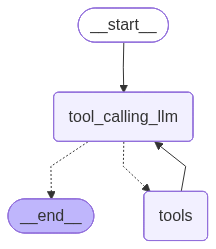

In [22]:
## State graph
from langgraph.graph import StateGraph,START,END
from langgraph.prebuilt import ToolNode
from langgraph.prebuilt import tools_condition


## Node Definition
def tool_calling_llm(state:State):
    return {"messages":[llm_with_tool.invoke(state["messages"])]}


## Graph 
builder = StateGraph(State)
builder.add_node("tool_calling_llm",tool_calling_llm)
builder.add_node("tools",ToolNode(tools))

## Adding Edges

builder.add_edge(START,"tool_calling_llm")
builder.add_conditional_edges(
    "tool_calling_llm",
    # if the latest message (result) from assistant is a tool call -> tools_condition routes to tools
    # if the latest message (result) from assistant is not a tool call -> tools_condition routs to END
    tools_condition
)
builder.add_edge("tools","tool_calling_llm")

# Compile the graph

graph=builder.compile()
graph

In [23]:
### Asking both questions in one prompt with ReAct Agent

response=graph.invoke({"messages":"What is the latest news in AI and 45 multiplied by 109?"})
for m in response['messages']:
    m.pretty_print()

================================ Human Message =================================

What is the latest news in AI and 45 multiplied by 109?
================================== Ai Message ==================================
Tool Calls:
  tavily_search (1p0mxj2h6)
 Call ID: 1p0mxj2h6
  Args:
    query: latest news in AI
    search_depth: advanced
    topic: general
================================= Tool Message =================================
Name: tavily_search

{"query": "latest news in AI", "follow_up_questions": null, "answer": null, "images": [], "results": [{"url": "https://www.artificialintelligence-news.com", "title": "AI News | Latest News | Insights Powering AI-Driven Business Growth", "content": "Retail & Logistics AI\n\nJune 11, 2026\n\n### How C3 AI agents will automate predictive maintenance for Shell\n\nAI in Action\n\nJune 5, 2026\n\n#### Industries\n\n### Omio scales travel product development using OpenAI models\n\nAI in Action\n\nJune 23, 2026\n\n### L’Oréal brings Maybe

### Adding Memory in Agentic Agent

In [24]:
response=graph.invoke({"messages":"Hello my name is Bharadwaj"})
for m in response['messages']:
    m.pretty_print()

================================ Human Message =================================

Hello my name is Bharadwaj
================================== Ai Message ==================================

Hello Bharadwaj, it's nice to meet you. Is there something I can help you with or would you like to chat?


In [25]:
response=graph.invoke({"messages":"What is my name?"})
for m in response['messages']:
    m.pretty_print()

================================ Human Message =================================

What is my name?
================================== Ai Message ==================================

I don't have any information about your name. This conversation just started, and I don't have any prior knowledge about you. If you'd like to share your name, I'd be happy to chat with you!


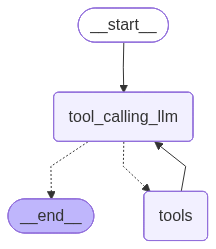

In [26]:
## State graph
from langgraph.graph import StateGraph,START,END
from langgraph.prebuilt import ToolNode
from langgraph.prebuilt import tools_condition
from langgraph.checkpoint.memory import MemorySaver

memory = MemorySaver()

## Node Definition
def tool_calling_llm(state:State):
    return {"messages":[llm_with_tool.invoke(state["messages"])]}


## Graph 
builder = StateGraph(State)
builder.add_node("tool_calling_llm",tool_calling_llm)
builder.add_node("tools",ToolNode(tools))

## Adding Edges

builder.add_edge(START,"tool_calling_llm")
builder.add_conditional_edges(
    "tool_calling_llm",
    # if the latest message (result) from assistant is a tool call -> tools_condition routes to tools
    # if the latest message (result) from assistant is not a tool call -> tools_condition routs to END
    tools_condition
)
builder.add_edge("tools","tool_calling_llm")

# Compile the graph

graph=builder.compile(checkpointer=memory)
graph



In [27]:
### In order to save the memory we need to generate a Thread ID 

config={"configurable":{"thread_id":"1"}}
response = graph.invoke({"messages":"Hi my name is Bharadwaj"},config=config)
response

{'messages': [HumanMessage(content='Hi my name is Bharadwaj', additional_kwargs={}, response_metadata={}, id='0c79f37a-d097-45a5-85e3-0ef1ab777835'),
  AIMessage(content="Hello Bharadwaj, it's nice to meet you. Is there something I can help you with or would you like to chat?", additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 29, 'prompt_tokens': 1753, 'total_tokens': 1782, 'completion_time': 0.087132666, 'completion_tokens_details': None, 'prompt_time': 0.098429344, 'prompt_tokens_details': None, 'queue_time': 0.057360584, 'total_time': 0.18556201}, 'model_name': 'llama-3.3-70b-versatile', 'system_fingerprint': 'fp_dae98b5ecb', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019f0d9f-3417-7bb2-b86d-c4860924b209-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 1753, 'output_tokens': 29, 'total_tokens': 1782})]}

In [28]:
response['messages'][-1].content

"Hello Bharadwaj, it's nice to meet you. Is there something I can help you with or would you like to chat?"

In [29]:
response=graph.invoke({"messages":"What is my name?"},config=config)
response['messages'][-1].content


'Your name is Bharadwaj.'

### Streaming

In [37]:
from langgraph.checkpoint.memory import MemorySaver
memory=MemorySaver() 

In [38]:
def superbot(state:State):
    return {"messages":[llm.invoke(state['messages'])]}

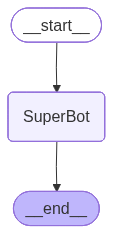

In [39]:
graph=StateGraph(State)

# node
graph.add_node("SuperBot",superbot)

# edges
graph.add_edge(START,"SuperBot")
graph.add_edge("SuperBot",END)

graph_builder=graph.compile(checkpointer=memory)

# dislay
graph_builder

In [40]:
## Invocation 

config={"configurable":{"thread_id":"1"}}
response = graph_builder.invoke({"messages":"Hi my name is Bharadwaj and I like Cricket"},config)
response

{'messages': [HumanMessage(content='Hi my name is Bharadwaj and I like Cricket', additional_kwargs={}, response_metadata={}, id='d1776270-116b-496d-8288-dd91820fae8b'),
  AIMessage(content="Nice to meet you, Bharadwaj. Cricket is an exciting sport, and India has a rich cricketing history. Who's your favorite cricketer, past or present? Are you a fan of the Indian Premier League (IPL) or do you prefer international cricket?", additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 58, 'prompt_tokens': 47, 'total_tokens': 105, 'completion_time': 0.164644615, 'completion_tokens_details': None, 'prompt_time': 0.00294662, 'prompt_tokens_details': None, 'queue_time': 0.05278761, 'total_time': 0.167591235}, 'model_name': 'llama-3.3-70b-versatile', 'system_fingerprint': 'fp_dae98b5ecb', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019f0db6-fdf8-7ee0-adec-c34f24b183d3-0', tool_calls=[], invalid_tool_calls=[]

Methods: stream() and astream()

    1) these methods are sync and async methods for streaming back results

In [ ]:
# Create a thread with stream method
config = {"configurable": {"thread_id":"3"}}

for chunk in graph_builder.stream({'messages':"Hi,My name is Bharadwaj and I like Cricket ="},config,stream_mode="updates"):
    print(chunk)


{'SuperBot': {'messages': [AIMessage(content='Nice to meet you, Bharadwaj. Cricket is an exciting sport with a huge following worldwide. Are you a fan of a particular team or player? Do you have a favorite format, such as Test matches, ODIs, or T20s?', additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 53, 'prompt_tokens': 49, 'total_tokens': 102, 'completion_time': 0.152006884, 'completion_tokens_details': None, 'prompt_time': 0.002194025, 'prompt_tokens_details': None, 'queue_time': 0.056091265, 'total_time': 0.154200909}, 'model_name': 'llama-3.3-70b-versatile', 'system_fingerprint': 'fp_dae98b5ecb', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019f0dc1-db42-7483-be80-4251b6c43841-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 49, 'output_tokens': 53, 'total_tokens': 102})]}}


In [42]:
for chunk in graph_builder.stream({'messages':"Hi,My name is Bharadwaj and I like Cricket ="},config,stream_mode="values"):
    print(chunk)


{'messages': [HumanMessage(content='Hi,My name is Bharadwaj and I like Cricket =', additional_kwargs={}, response_metadata={}, id='e47793c9-0549-4021-a317-9ede87125918'), AIMessage(content='Nice to meet you, Bharadwaj. Cricket is an exciting sport with a huge following worldwide. Are you a fan of a particular team or player? Do you have a favorite format, such as Test matches, ODIs, or T20s?', additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 53, 'prompt_tokens': 49, 'total_tokens': 102, 'completion_time': 0.152006884, 'completion_tokens_details': None, 'prompt_time': 0.002194025, 'prompt_tokens_details': None, 'queue_time': 0.056091265, 'total_time': 0.154200909}, 'model_name': 'llama-3.3-70b-versatile', 'system_fingerprint': 'fp_dae98b5ecb', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019f0dc1-db42-7483-be80-4251b6c43841-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_token

In [54]:
# Create a thread using astream method

config = {"configurable": {"thread_id":"5"}}

async for event in graph_builder.astream_events({"messages":["Hi,My name is Bharadwaj and I like Cricket"]},config,version="v2"):
    print(event)
    

{'event': 'on_chain_start', 'data': {'input': {'messages': ['Hi,My name is Bharadwaj and I like Cricket']}}, 'name': 'LangGraph', 'tags': [], 'run_id': '019f0dd0-c769-7d43-a642-6be18cbcdb5a', 'metadata': {'thread_id': '5', 'ls_integration': 'langgraph'}, 'parent_ids': []}
{'event': 'on_chain_start', 'data': {'input': {'messages': [HumanMessage(content='Hi,My name is Bharadwaj and I like Cricket', additional_kwargs={}, response_metadata={}, id='19aea9dc-f44e-43b0-bdab-590b2c7393a2')]}}, 'name': 'SuperBot', 'tags': ['graph:step:1'], 'run_id': '019f0dd0-c771-7f63-bf29-3187432f506b', 'metadata': {'thread_id': '5', 'ls_integration': 'langgraph', 'langgraph_step': 1, 'langgraph_node': 'SuperBot', 'langgraph_triggers': ('branch:to:SuperBot',), 'langgraph_path': ('__pregel_pull', 'SuperBot'), 'langgraph_checkpoint_ns': 'SuperBot:2c9e5978-90b1-80b6-6382-ea6d2bb4fea9'}, 'parent_ids': ['019f0dd0-c769-7d43-a642-6be18cbcdb5a']}
{'event': 'on_chat_model_start', 'data': {'input': {'messages': [[Human